In [1]:
import json

import torch

from models.LightningDiT import LightningDiT, LightningDiTConfig
from custom_datasets.pokemon_dataset import PokemonDataset
from training.train_transformer import train_drifting, prepare_vae
from training.utils import get_number_of_parameters

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE = 128

In [3]:
vae_name = "flux-vae"

vae_kwargs = {
    "device_map": "cuda:0",
    "torch_dtype": torch.bfloat16,
}

vae, latent_shape = prepare_vae(
    vae_name="flux_vae",
    path_to_vae="./checkpoints/flux_vae",
    img_size=IMG_SIZE,
    vae_kwargs=vae_kwargs
)

print("VAE:")
get_number_of_parameters(vae)

vae = torch.compile(vae, mode="reduce-overhead")

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


VAE:
Params: 84M


In [4]:
config_path = "/home/msst/repo/drifting/checkpoints/config_ViT-B2_flux-vae_128.json"
with open(config_path, "r") as f:
    config_dict = json.load(f)

vit_config = LightningDiTConfig.from_dict(config_dict)
# print(vit_config)
vit = LightningDiT(vit_config).cuda()
print("ViT")
get_number_of_parameters(vit)

opt = torch.optim.AdamW(
    vit.parameters(), 
    lr=2e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

ViT
Params: 85.3M


In [5]:
from accelerate import init_empty_weights
from models.advanced_deature_encoder import FeatureExtractor, MAEResNet

with init_empty_weights():
    mae_resnet = MAEResNet(
            in_channels = latent_shape[0],
            base_channels = 384,
            mask_patch_size = 2,
            input_patch_size = 1,
            layers = (3, 4, 6, 3),
        )
mae_resnet = mae_resnet.to_empty(device="cuda:0")
mae_resnet = torch.compile(mae_resnet, mode="reduce-overhead")
mae_resnet.load_state_dict(
    torch.load(
        "/home/msst/repo/drifting/checkpoints/CelebA/MAE_flux-vae_ch384_img128/CelebA/epochs92.pth"
        )
    )
feature_encoder = FeatureExtractor(
    encoder=mae_resnet.encoder.to(torch.bfloat16).cuda(),
    input_patch_size=mae_resnet.input_patch_size,
    every_k_block=2
)

print("Feature encoder:")
get_number_of_parameters(feature_encoder)

Feature encoder:
Params: 766M


In [6]:
dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

dataset = PokemonDataset(
    root_dir=dataset_path, 
    img_size=IMG_SIZE, 
    dataset_type=dataset_type
)

Number of images: 202599


Saved image to checkpoints/CelebA/transformer_img128_ps2_flux-vae/gen_images_2000.png


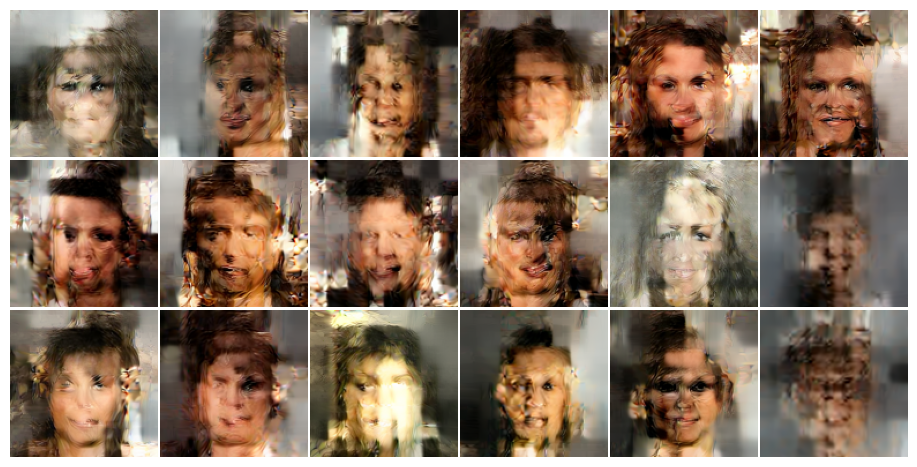

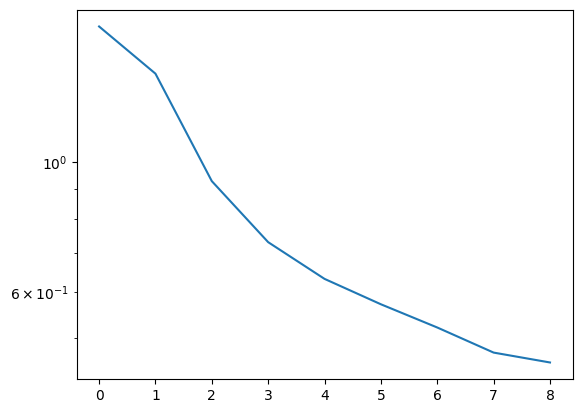

  1%|          | 2000/250000 [19:39<53:23:15,  1.29it/s, loss=4.34e-01]

V_abs 0.123046875
V_abs 0.0966796875
V_abs 0.0888671875
V_abs 0.08349609375
V_abs 0.083984375


  1%|          | 2160/250000 [21:10<40:46:17,  1.69it/s, loss=4.22e-01]

In [ ]:
loss_history = train_drifting(
    dataset=dataset,
    feature_encoder=feature_encoder,
    transformer=vit,
    vae=vae,
    opt=opt,
    noise_shape=latent_shape,
    T_list=[0.2, 0.5, 2.0],
    batch_size=128,
    gradient_accumulation=2,
    training_steps=250000,
    plot_every=250,
    seed=None,
    loss_scaling=1.0e3,
    save_step=1000,
    save_path=f"checkpoints/CelebA/transformer_img{IMG_SIZE}_ps{vit.patch_size}_{vae_name}",
)